# Задание (PyTorch-версия)

Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9 моделей** нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке. Используйте следующее деление: обучающая выборка — **50000** примеров, проверочная выборка — **10000** примеров, тестовая выборка — **10000** примеров.
2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведённых тестов.

Все 9 моделей реализованы на **PyTorch**.


# Шаблон ноутбука

## Импорт библиотек


In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Загрузка датасета
from torchvision import datasets, transforms

# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Отрисовывать изображения в ноутбуке
%matplotlib inline

# Фиксируем seed для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Выбор устройства (GPU если доступен)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)


Устройство: cpu


## Описание базы

### База: одежда, обувь и аксессуары

- Датасет состоит из набора изображений одежды, обуви, аксессуаров и их классов.
- Изображения одного вида хранятся в массиве **(28, 28)**.
- База содержит **10 классов**: (Футболка, Брюки, Пуловер, Платье, Пальто, Сандалии/Босоножки, Рубашка, Кроссовки, Сумочка, Ботильоны).
- Примеров: train — **60000**, test — **10000**.

### Загрузка и вывод примеров


In [2]:
# Загрузка Fashion-MNIST через torchvision
# transforms.ToTensor() автоматически делает нормализацию в [0, 1]
transform = transforms.ToTensor()

train_dataset_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset       = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Извлекаем numpy-массивы для дальнейшей работы (как в Keras-версии)
x_train_full = train_dataset_full.data.numpy()   # (60000, 28, 28)
y_train_full = train_dataset_full.targets.numpy()
x_test       = test_dataset.data.numpy()         # (10000, 28, 28)
y_test       = test_dataset.targets.numpy()

print('Размер x_train_full:', x_train_full.shape)
print('Размер y_train_full:', y_train_full.shape)
print('Размер x_test:      ', x_test.shape)
print('Размер y_test:      ', y_test.shape)


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.8MB/s]

Размер x_train_full: (60000, 28, 28)
Размер y_train_full: (60000,)
Размер x_test:       (10000, 28, 28)
Размер y_test:       (10000,)


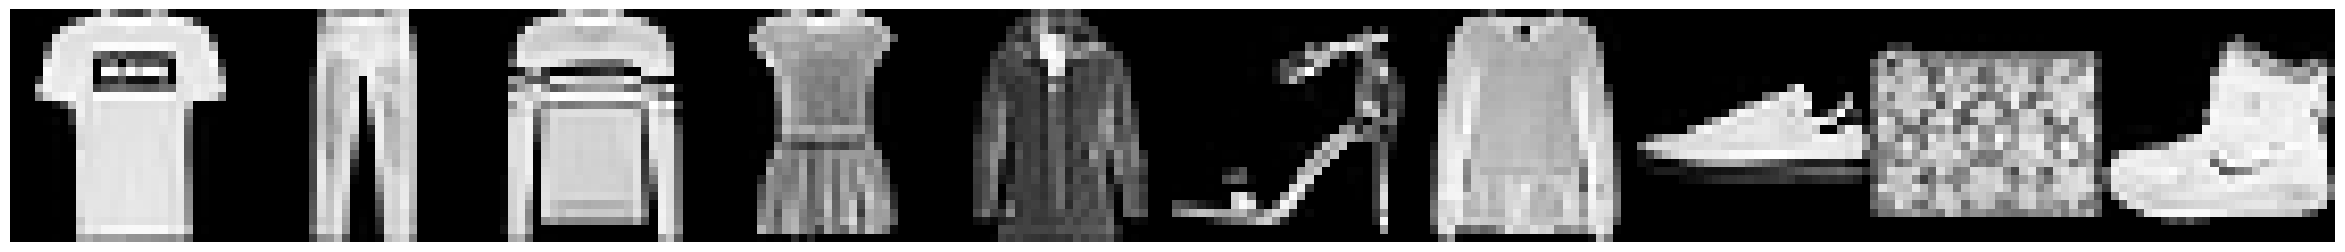

In [3]:
# Выбор 1 изображения каждого класса
imgs = np.array([x_train_full[y_train_full==i][0] for i in range(10)])

# Соединение изображений в одну линию
imgs = np.concatenate(imgs, axis=1)

# Создание поля для изображения
plt.figure(figsize=(30, 6))

# Отрисовка итогового изображения
plt.imshow(imgs, cmap='Greys_r')

# Без сетки
plt.grid(False)

# Без осей
plt.axis('off')

# Вывод результата
plt.show()


---

# Решение задания

## Подготовка данных

Согласно заданию, делим выборки так:
- обучающая — **50000** примеров
- проверочная — **10000** примеров
- тестовая — **10000** примеров

В `fashion_mnist` изначально train = 60000, test = 10000. Тестовую берём как есть, а train делим на обучающую (50000) и проверочную (10000) с помощью `train_test_split`.


In [4]:
# Разделение train-выборки на обучающую (50000) и проверочную (10000)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=10000,     # ровно 10000 примеров в валидацию
    shuffle=True,        # перемешиваем
    random_state=42      # воспроизводимость
)

print('Обучающая выборка:  ', x_train.shape, y_train.shape)
print('Валидационная:      ', x_val.shape,   y_val.shape)
print('Тестовая:           ', x_test.shape,  y_test.shape)


Обучающая выборка:   (50000, 28, 28) (50000,)
Валидационная:       (10000, 28, 28) (10000,)
Тестовая:            (10000, 28, 28) (10000,)


In [5]:
# Преобразование к формату (N, 784) и нормализация в диапазон [0, 1]
x_train = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.
x_val   = x_val.reshape(x_val.shape[0], -1).astype('float32') / 255.
x_test  = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.

# Перевод в тензоры PyTorch
x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_val_t   = torch.tensor(x_val,   dtype=torch.float32)
x_test_t  = torch.tensor(x_test,  dtype=torch.float32)

# Метки как long (для CrossEntropyLoss)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print('x_train_t:', x_train_t.shape, ' y_train_t:', y_train_t.shape)
print('x_val_t:  ', x_val_t.shape,   ' y_val_t:  ', y_val_t.shape)
print('x_test_t: ', x_test_t.shape,  ' y_test_t: ', y_test_t.shape)


x_train_t: torch.Size([50000, 784])  y_train_t: torch.Size([50000])
x_val_t:   torch.Size([10000, 784])  y_val_t:   torch.Size([10000])
x_test_t:  torch.Size([10000, 784])  y_test_t:  torch.Size([10000])


In [6]:
# DataLoader'ы для батчевого обучения
BATCH_SIZE = 256

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)


### Важный момент про функцию потерь

В PyTorch используем `nn.CrossEntropyLoss` — она **внутри уже делает softmax**, поэтому последний слой наших моделей **не содержит активации softmax** (оставляем «сырые» логиты). Это стандартная практика PyTorch и аналог `categorical_crossentropy` + `softmax` из Keras.


## Вспомогательные функции

Чтобы не дублировать код при обучении 9 моделей, напишем:
- функцию оценки `evaluate()` — считает точность и loss на любом loader'е;
- функцию `train_and_evaluate()` — обучает модель с аналогом EarlyStopping (останавливается, если `val_loss` не улучшается 3 эпохи подряд), возвращает результаты.


In [7]:
def evaluate(model, loader, criterion):
    """Считает loss и accuracy на переданном DataLoader."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total


In [8]:
def train_and_evaluate(model, name, optimizer=None, epochs=30, patience=3, verbose=False):
    """Обучает модель с EarlyStopping и возвращает точность на val (посл. эпоха) и на test."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    epochs_done = 0

    for epoch in range(epochs):
        # --- тренировка ---
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss /= total
        train_acc = correct / total

        # --- валидация ---
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        epochs_done += 1

        if verbose:
            print(f'  Эпоха {epoch+1:>2}: loss={train_loss:.4f} acc={train_acc:.4f} '
                  f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        # --- аналог EarlyStopping с restore_best_weights ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    # Восстанавливаем лучшие веса
    if best_state is not None:
        model.load_state_dict(best_state)

    # Точность на валидации на последней эпохе обучения (по заданию)
    val_acc_last = history['val_accuracy'][-1]

    # Точность на тесте
    _, test_acc = evaluate(model, test_loader, criterion)

    print(f'[{name}]  эпох: {epochs_done:>2}   '
          f'val_accuracy (посл. эпоха): {val_acc_last:.4f}   '
          f'test_accuracy: {test_acc:.4f}')

    return {
        'name': name,
        'val_accuracy': val_acc_last,
        'test_accuracy': test_acc,
        'epochs_done': epochs_done,
        'history': history
    }

# Список для результатов всех моделей
results = []


## Модель 1 — однослойная (128 нейронов)

Минимально простая архитектура. Согласно теории — с неё рекомендуется начинать.


In [9]:
model_1 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)   # без softmax — он внутри CrossEntropyLoss
)

results.append(train_and_evaluate(model_1, 'М1: однослойная 128'))


[М1: однослойная 128]  эпох: 23   val_accuracy (посл. эпоха): 0.8897   test_accuracy: 0.8827


## Модель 2 — однослойная (256 нейронов)

Та же архитектура, но больше нейронов. Проверим, даёт ли расширение слоя прирост.


In [10]:
model_2 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

results.append(train_and_evaluate(model_2, 'М2: однослойная 256'))


[М2: однослойная 256]  эпох: 16   val_accuracy (посл. эпоха): 0.8865   test_accuracy: 0.8843


## Модель 3 — двуслойная (128 → 64)

Добавляем второй скрытый слой.


In [11]:
model_3 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

results.append(train_and_evaluate(model_3, 'М3: двуслойная 128 → 64'))


[М3: двуслойная 128 → 64]  эпох: 12   val_accuracy (посл. эпоха): 0.8663   test_accuracy: 0.8685


## Модель 4 — двуслойная (256 → 128)

Более широкая двуслойная сеть.


In [12]:
model_4 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

results.append(train_and_evaluate(model_4, 'М4: двуслойная 256 → 128'))


[М4: двуслойная 256 → 128]  эпох: 10   val_accuracy (посл. эпоха): 0.8762   test_accuracy: 0.8788


## Модель 5 — трёхслойная (512 → 256 → 128)

Глубокая сеть. Проверим, помогает ли рост глубины.


In [13]:
model_5 = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

results.append(train_and_evaluate(model_5, 'М5: трёхслойная 512 → 256 → 128'))


[М5: трёхслойная 512 → 256 → 128]  эпох: 10   val_accuracy (посл. эпоха): 0.8832   test_accuracy: 0.8807


## Модель 6 — с Dropout

Двуслойная 256 → 128 с регуляризацией Dropout. Согласно теории, Dropout случайно отключает часть нейронов в каждом батче — это борьба с переобучением.


In [14]:
model_6 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

results.append(train_and_evaluate(model_6, 'М6: 256 → Dropout → 128 → Dropout'))


[М6: 256 → Dropout → 128 → Dropout]  эпох: 28   val_accuracy (посл. эпоха): 0.8945   test_accuracy: 0.8930


## Модель 7 — с BatchNormalization

Пакетная нормализация стандартизирует распределение выходов нейронов, позволяет увеличить шаг обучения и уменьшает чувствительность к начальным весам.

В PyTorch для полносвязных слоёв используется `nn.BatchNorm1d(num_features)`.


In [15]:
model_7 = nn.Sequential(
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

results.append(train_and_evaluate(model_7, 'М7: 256 → BN → 128 → BN'))


[М7: 256 → BN → 128 → BN]  эпох:  6   val_accuracy (посл. эпоха): 0.8545   test_accuracy: 0.8644


## Модель 8 — Dropout + BatchNormalization

Комбинируем оба инструмента регуляризации на глубокой сети.


In [16]:
model_8 = nn.Sequential(
    nn.Linear(784, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 10)
)

results.append(train_and_evaluate(model_8, 'М8: глубокая + BN + Dropout'))


[М8: глубокая + BN + Dropout]  эпох: 14   val_accuracy (посл. эпоха): 0.8873   test_accuracy: 0.8822


## Модель 9 — другой оптимизатор (Adadelta)

Архитектура как у модели 4 (256 → 128), но оптимизатор — `Adadelta`. Проверим влияние гиперпараметра «алгоритм оптимизации».


In [17]:
model_9 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_9 = optim.Adadelta(model_9.parameters(), lr=1.0)
results.append(train_and_evaluate(model_9, 'М9: 256 → 128 (Adadelta)',
                                  optimizer=optimizer_9))


[М9: 256 → 128 (Adadelta)]  эпох: 14   val_accuracy (посл. эпоха): 0.8793   test_accuracy: 0.8788


---

## Сравнительная таблица результатов


In [18]:
# Собираем результаты в DataFrame
df_results = pd.DataFrame([
    {
        '№': i + 1,
        'Архитектура': r['name'],
        'Эпох пройдено': r['epochs_done'],
        'val_accuracy (посл. эпоха)': round(r['val_accuracy'], 4),
        'test_accuracy': round(r['test_accuracy'], 4),
    }
    for i, r in enumerate(results)
])

# Сортировка по точности на тесте
df_results_sorted = df_results.sort_values('test_accuracy', ascending=False).reset_index(drop=True)

print('=== Результаты в порядке добавления ===')
print(df_results.to_string(index=False))
print()
print('=== Результаты, отсортированные по test_accuracy ===')
print(df_results_sorted.to_string(index=False))


=== Результаты в порядке добавления ===
 №                       Архитектура  Эпох пройдено  val_accuracy (посл. эпоха)  test_accuracy
 1               М1: однослойная 128             23                      0.8897         0.8827
 2               М2: однослойная 256             16                      0.8865         0.8843
 3           М3: двуслойная 128 → 64             12                      0.8663         0.8685
 4          М4: двуслойная 256 → 128             10                      0.8762         0.8788
 5   М5: трёхслойная 512 → 256 → 128             10                      0.8832         0.8807
 6 М6: 256 → Dropout → 128 → Dropout             28                      0.8945         0.8930
 7           М7: 256 → BN → 128 → BN              6                      0.8545         0.8644
 8       М8: глубокая + BN + Dropout             14                      0.8873         0.8822
 9          М9: 256 → 128 (Adadelta)             14                      0.8793         0.8788

=== Резул

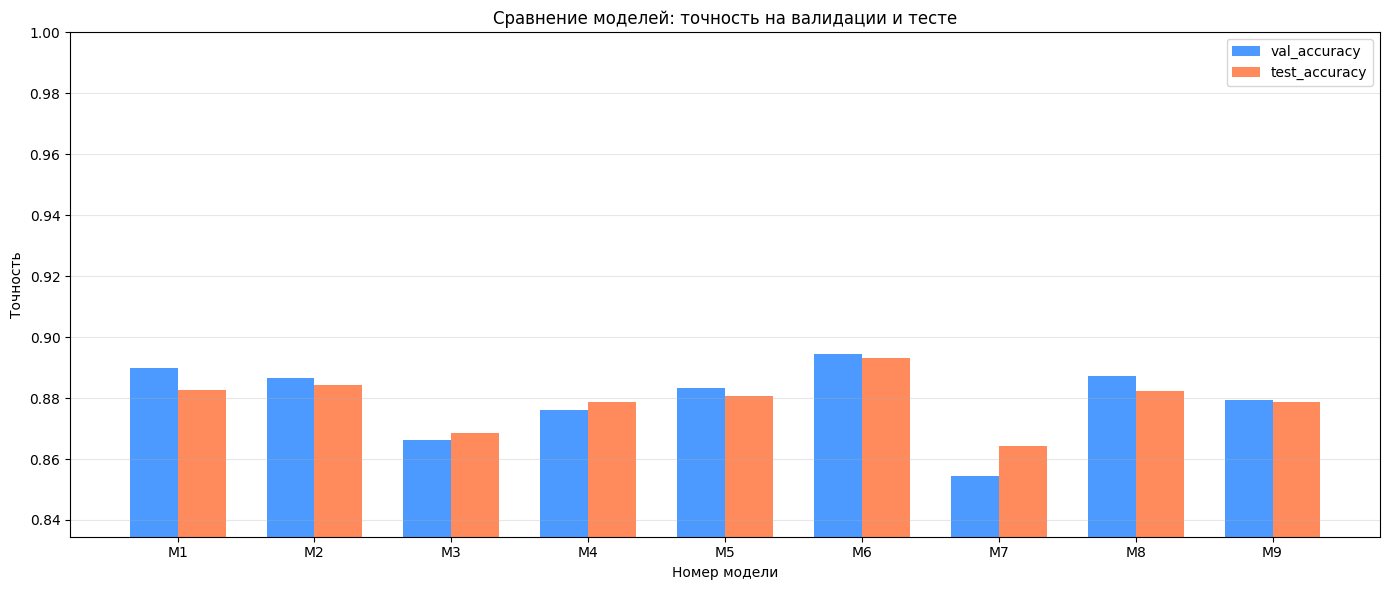

In [19]:
# Визуализация — столбчатая диаграмма
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(len(results))
width = 0.35

val_scores  = [r['val_accuracy']  for r in results]
test_scores = [r['test_accuracy'] for r in results]

ax.bar(x_pos - width/2, val_scores,  width, label='val_accuracy',  color='#4C9AFF')
ax.bar(x_pos + width/2, test_scores, width, label='test_accuracy', color='#FF8B5C')

ax.set_xlabel('Номер модели')
ax.set_ylabel('Точность')
ax.set_title('Сравнение моделей: точность на валидации и тесте')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'М{i+1}' for i in range(len(results))])
ax.set_ylim(min(min(val_scores), min(test_scores)) - 0.02, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


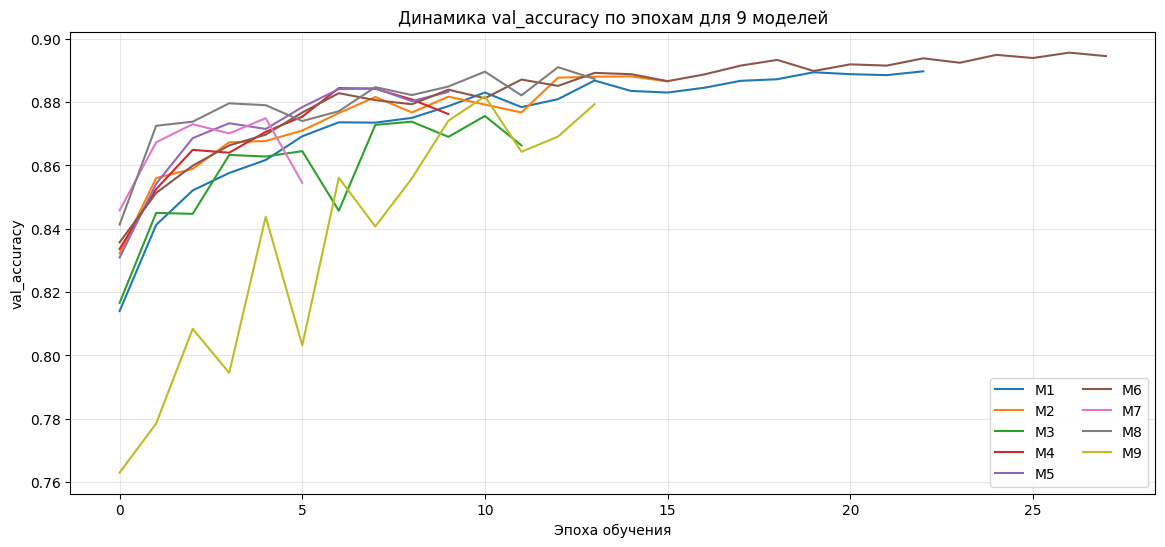

In [20]:
# Графики обучения (val_accuracy по эпохам) для всех моделей
plt.figure(figsize=(14, 6))
for i, r in enumerate(results):
    plt.plot(r['history']['val_accuracy'], label=f'М{i+1}')
plt.xlabel('Эпоха обучения')
plt.ylabel('val_accuracy')
plt.title('Динамика val_accuracy по эпохам для 9 моделей')
plt.legend(loc='lower right', ncol=2)
plt.grid(alpha=0.3)
plt.show()
